# Лабораторная работа 7. 
# Классификация методом k ближайших соседей и наивным байесовским классификатором

В данной работе вы 
1. на примере классического датасета "Ирисы Фишера" 
- научитесь проводить классификациию методами kNN и NaiveBayes, используя средства библиотеки `scikit-learn`
- изучите способы оценки качества моделей для случая многоклассовой классификации
2. познакомитесь с платформой Kaggle, и для датасета с этой платформы решите задачу классификации двумя изученными методами, сравните качество полученных моделей.


## Классификация ирисов Фишера

#### Импорт библиотек и загрузка данных

In [1]:
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn import datasets, model_selection
from sklearn.naive_bayes import GaussianNB # Гауссовский нивный классификатор
from sklearn.neighbors import KNeighborsClassifier # Классификатор k ближайших соседей
#plt.style.use('seaborn-darkgrid')
#plt.rc('figure', figsize=(16,10))
#plt.rc('lines', markersize=4)

In [2]:
iris_loaded = datasets.load_iris() # загрузка встроенного в библиотеку sklearn.datasets набора данных с ирисами
iris=pd.DataFrame(iris_loaded.data, columns=iris_loaded.feature_names)
iris['target']=iris_loaded.target_names[iris_loaded.target]
iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


#### Кодирование категориальных данных, разбиение данных на тренировочную и тестовую выборки

In [3]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
coder=LabelEncoder() # В данной задаче воспользуемся только кодированием LabelEncoder

In [4]:
iris_train, iris_test=model_selection.train_test_split(iris, test_size=0.3) 
X_train, y_train = iris_train.drop(['target'], axis=1), iris_train.target # отделяем столбец с откликом из тренировочной и тестовой выборок
X_test, y_test = iris_test.drop(['target'], axis=1), iris_test.target

y_train=coder.fit_transform(y_train) # обучаем кодер LabelEncoder на y_train (fit) и сразу же применяем его к y_train (transform)
y_test=coder.transform(y_test) # применяем обученный кодер к тестовой выборке

#### Обучение классификатора kNN c параметрами по умолчанию на тренировочной выборке

In [5]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


#### Оценка качества на тестовой выборке
В нашей задаче три класса, поэтому вычислять метрики качества как в задаче бинарной классификации не получится. По ссылке
[Метрики для многоклассовой классификации](https://ml-handbook.ru/chapters/model_evaluation/intro#%D0%BC%D0%BD%D0%BE%D0%B3%D0%BE%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%BE%D0%B2%D0%B0%D1%8F-%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D1%8F) изучите способы вычисления метрик для случая более 2 классов.

Технически мы будем пользоваться теми же средствами пакета `sklearn.metrics`, что и для бинарного случая, но дополнительно указывать способ усреднения метрик (микро- или макроусреднение) (аргумент функций метрик `average`)

In [6]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [7]:
print("precision=", precision_score(knn.predict(X_test),y_test, average='macro'))
print("recall=", recall_score(knn.predict(X_test),y_test,average='macro'))
print("accuracy=", accuracy_score(knn.predict(X_test),y_test))

precision= 0.9555555555555556
recall= 0.9629629629629629
accuracy= 0.9555555555555556


Вывод на экран матрицы неточностей

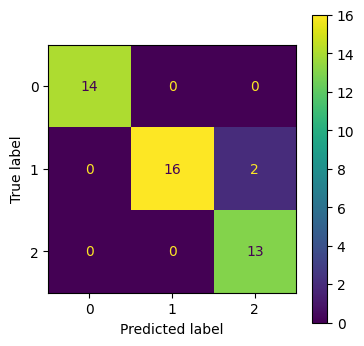

In [8]:
cm=confusion_matrix(knn.predict(X_test), y_test)
fig=plt.figure(figsize = (4, 4))
ax = fig.add_subplot(111)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
# display_labels=coder.inverse_transform(knn.classes_))# раскомментируйте строку, если хотите, чтоьы вместо меток классов отображались названия
 display_labels=knn.classes_)# закомментируйте строку, если хотите, чтоьы вместо меток классов отображались названия
disp.plot(ax=ax)
ax.grid(False)

#### Прогнозирование c помощью kNN на новых данных 

In [9]:
# Какой сорт будет у ириса с чашелистником размера 5 x 3.2 и лепестками размера 4.2 x 2
X_pred = [5, 3.2, 4.2, 2]
result = knn.predict([X_pred, ]) 

result_name=coder.inverse_transform(result) # от числовой метки класса переходим назад к названиям с помошью метода кодера inverse_transform
result_name

c:\Users\dpomi\source\repos\data_science\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array(['versicolor'], dtype=object)

#### Обучение классификатора GaussianNaiveBayes c параметрами по умолчанию на тренировочной выборке

In [10]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


#### Оценка качества на тестовой выборке

In [11]:
print("precision=", precision_score(gnb.predict(X_test),y_test, average='macro'))
print("recall=", recall_score(gnb.predict(X_test),y_test,average='macro'))
print("accuracy=", accuracy_score(gnb.predict(X_test),y_test))

precision= 0.9555555555555556
recall= 0.9629629629629629
accuracy= 0.9555555555555556


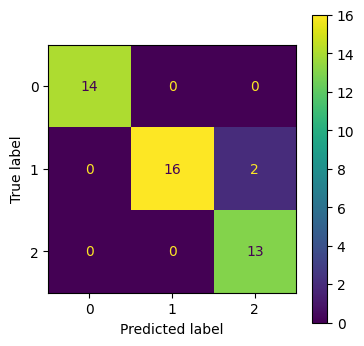

In [12]:
cm=confusion_matrix(gnb.predict(X_test), y_test)
fig=plt.figure(figsize = (4, 4))
ax = fig.add_subplot(111)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
# display_labels=coder.inverse_transform(knn.classes_))# раскомментируйте строку, если хотите, чтоьы вместо меток классов отображались названия
 display_labels=knn.classes_)# закомментируйте строку, если хотите, чтоьы вместо меток классов отображались названия
disp.plot(ax=ax)
ax.grid(False)

#### Прогнозирование c помощью GaussianNaiveBayes на новых данных 

In [13]:
# Какой сорт будет у ириса с чашелистником размера 5 x 3.2 и лепестками размера 4.2 x 2

result = gnb.predict([X_pred, ])

result_name=coder.inverse_transform(result)
result_name

c:\Users\dpomi\source\repos\data_science\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


array(['virginica'], dtype=object)

📌📌📌 **Задание для вариантов 1-3**

1.Загрузите датасеты, изучите информацию про них на платформе Kaggle:
- **Вариант 1** [Pima Indians Diabetes Database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)
- **Вариант 2** [Fraud Detection](https://www.kaggle.com/datasets/whenamancodes/fraud-detection)
- **Вариант 3** [Blood Transfusion Dataset](https://www.kaggle.com/datasets/whenamancodes/blood-transfusion-dataset)

2. Подготовьте данные для анализа удалите строки с пропусками данных, лишние столбцы, не несущие полезной информации для прогнозирования (если будут), при необходимости примените кодирование LabelEncoding для отклика

3. Обучите и оцените качество для моделей kNN  и GaussianNaiveBayes c параметрами по умолчанию.

4. Попробуйте улучшить качество прогноза для kNN, выбрав другое количество ближайших соседей (не 5, как по умолчанию)

5. Какая из обученных вами моделей обладаем наилучшим качеством прогноза?

In [14]:
# Ваш код

📌📌📌 **Задание для варианта 4**

1.Загрузите датасет [Airline Passenger Satisfaction](https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction), изучите информацию про него на платформе Kaggle:

2. Подготовьте данные для анализа удалите строки с пропусками данных, лишние столбцы, не несущие полезной информации для прогнозирования (если будут),  при необходимости примените кодирование LabelEncoding для отклика

3. Обучите модели kNN  и GaussianNaiveBayes c параметрами по умолчанию ТОЛЬКО НА ЧИСЛОВЫХ ПРЕДИКТОРАХ, оцените качество моделей на тестовой выборке (обратите внимание, она у вас задана в отдельном файле)

3. Обучите модели kNN  и GaussianNaiveBayes c параметрами по умолчанию НА ВСЕХ ПРЕДИКТОРАХ, применив в категориальным переменным кодирование OneHotEncoding. Улучшилось ли качество?

4. Попробуйте еще улучшить качество прогноза для kNN, выбрав другое количество ближайших соседей (не 5, как по умолчанию)

5. Какая из обученных вами моделей обладаем наилучшим качеством прогноза?

In [32]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import precision_score, recall_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [33]:
df_train = pd.read_csv("train.csv")
df_train = df_train.drop(columns=['id', 'Unnamed: 0'])
df_train = df_train.dropna()

coder = LabelEncoder()
df_train['satisfaction'] = coder.fit_transform(df_train['satisfaction'])
df_train.head()

df_test = pd.read_csv("test.csv")
df_test = df_test.drop(columns=['id', 'Unnamed: 0'])
df_test = df_test.dropna()

coder = LabelEncoder()
df_test['satisfaction'] = coder.fit_transform(df_test['satisfaction'])
df_test.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Female,Loyal Customer,52,Business travel,Eco,160,5,4,3,4,...,5,5,5,5,2,5,5,50,44.0,1
1,Female,Loyal Customer,36,Business travel,Business,2863,1,1,3,1,...,4,4,4,4,3,4,5,0,0.0,1
2,Male,disloyal Customer,20,Business travel,Eco,192,2,0,2,4,...,2,4,1,3,2,2,2,0,0.0,0
3,Male,Loyal Customer,44,Business travel,Business,3377,0,0,0,2,...,1,1,1,1,3,1,4,0,6.0,1
4,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,4,3,...,2,2,2,2,4,2,4,0,20.0,1


# Только числовые

kNN Model:
precision= 0.7327762394834205
recall= 0.7392944939416931
accuracy= 0.7417834936083111


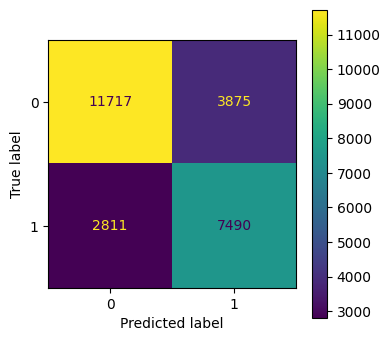

In [34]:
X_train, X_test, y_train, y_test = df_train.select_dtypes(include=[np.number]).drop(columns=['satisfaction']), df_test.select_dtypes(include=[np.number]).drop(columns=['satisfaction']), df_train['satisfaction'], df_test['satisfaction']
knn = KNeighborsClassifier()
knn.fit(X_train,y_train)
print("kNN Model:")
print("precision=", precision_score(knn.predict(X_test),y_test, average='macro'))
print("recall=", recall_score(knn.predict(X_test),y_test,average='macro'))
print("accuracy=", accuracy_score(knn.predict(X_test),y_test))
cm=confusion_matrix(knn.predict(X_test), y_test)
fig=plt.figure(figsize = (4, 4))
ax = fig.add_subplot(111)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
 display_labels=knn.classes_)
disp.plot(ax=ax)

Gaussian Naive Bayes Model:
precision= 0.7986247077112861
recall= 0.7950126261047341
accuracy= 0.7974356003553084


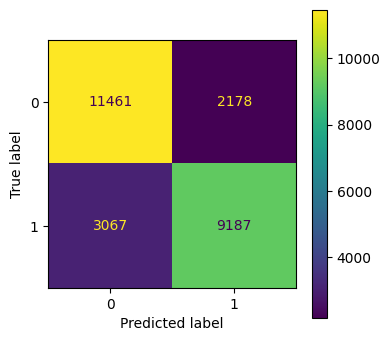

In [35]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
print("Gaussian Naive Bayes Model:")
print("precision=", precision_score(gnb.predict(X_test),y_test, average='macro'))
print("recall=", recall_score(gnb.predict(X_test),y_test,average='macro'))
print("accuracy=", accuracy_score(gnb.predict(X_test),y_test))
cm=confusion_matrix(gnb.predict(X_test), y_test)
fig=plt.figure(figsize = (4, 4))
ax = fig.add_subplot(111)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
    display_labels=gnb.classes_)
disp.plot(ax=ax)

kNN Model:
precision= 0.7260252362778141
recall= 0.7470900868839787
accuracy= 0.7418607345614645


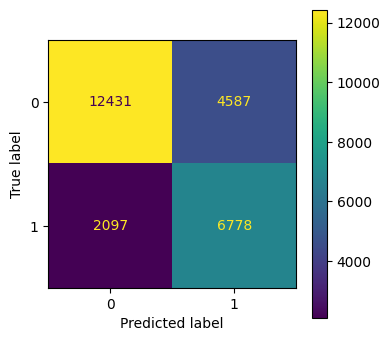

In [36]:
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train)
print("kNN Model:")
print("precision=", precision_score(knn.predict(X_test),y_test, average='macro'))
print("recall=", recall_score(knn.predict(X_test),y_test,average='macro'))
print("accuracy=", accuracy_score(knn.predict(X_test),y_test))
cm=confusion_matrix(knn.predict(X_test), y_test)
fig=plt.figure(figsize = (4, 4))
ax = fig.add_subplot(111)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
 display_labels=knn.classes_)
disp.plot(ax=ax)

# Все признаки

In [37]:
categorical_features = df_train.select_dtypes(include=['object']).columns.tolist()
numerical_features = df_train.select_dtypes(include=[np.number]).drop(columns=['satisfaction']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

X_train = preprocessor.fit_transform(df_train.drop(columns=['satisfaction']))
X_test = preprocessor.transform(df_test.drop(columns=['satisfaction']))



kNN Model:
precision= 0.7407999916661983
recall= 0.7465902416239105
accuracy= 0.7491213841578805


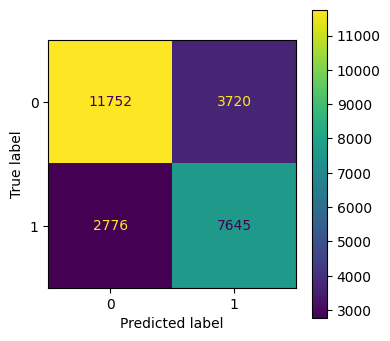

In [38]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
print("kNN Model:")
print("precision=", precision_score(knn.predict(X_test),y_test, average='macro'))
print("recall=", recall_score(knn.predict(X_test),y_test,average='macro'))
print("accuracy=", accuracy_score(knn.predict(X_test),y_test))
cm=confusion_matrix(knn.predict(X_test), y_test)
fig=plt.figure(figsize = (4, 4))
ax = fig.add_subplot(111)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
 display_labels=knn.classes_)
disp.plot(ax=ax)

Gaussian Naive Bayes Model:
precision= 0.840718615968727
recall= 0.8423140358178007
accuracy= 0.8441663770130924


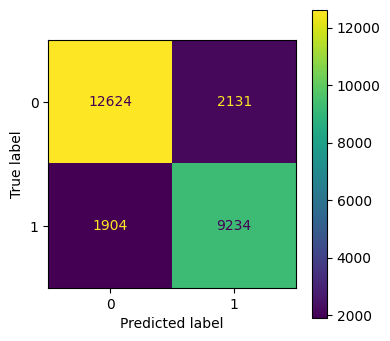

In [39]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
print("Gaussian Naive Bayes Model:")
print("precision=", precision_score(gnb.predict(X_test),y_test, average='macro'))
print("recall=", recall_score(gnb.predict(X_test),y_test,average='macro'))
print("accuracy=", accuracy_score(gnb.predict(X_test),y_test))
cm=confusion_matrix(gnb.predict(X_test), y_test)
fig=plt.figure(figsize = (4, 4))
ax = fig.add_subplot(111)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
    display_labels=gnb.classes_)
disp.plot(ax=ax)

kNN Model:
precision= 0.734823190159912
recall= 0.7556566766255319
accuracy= 0.7501641370254509


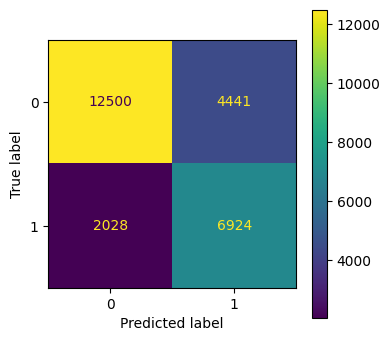

In [40]:
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train)
print("kNN Model:")
print("precision=", precision_score(knn.predict(X_test),y_test, average='macro'))
print("recall=", recall_score(knn.predict(X_test),y_test,average='macro'))
print("accuracy=", accuracy_score(knn.predict(X_test),y_test))
cm=confusion_matrix(knn.predict(X_test), y_test)
fig=plt.figure(figsize = (4, 4))
ax = fig.add_subplot(111)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
 display_labels=knn.classes_)
disp.plot(ax=ax)